In [17]:
import sys
sys.path.append('/Users/chonge/Documents/Document/University_of_Chicago/transaction_project')
from models import MF, FM, DeepFM, RecSys

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import datetime as dt
import math
import random 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchmetrics.regression import MeanSquaredError
from sklearn.metrics import precision_score, recall_score
from torch import nn
from torchsummary import summary
from torchviz import make_dot
import torch.nn.functional as F
from itertools import product


In [19]:
# %load_ext tensorboard
%matplotlib inline
sbn.set_style("whitegrid")

In [20]:
# set seed
seed = 107
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [21]:
model_path = '/Users/chonge/Documents/Document/University_of_Chicago/transaction_project/models/binary_classification'

In [22]:
# key hyperparameters
num_features = 38
batch_size = 16

### Load the data 

In [23]:
user_item_table = pd.read_csv('../final_data/user_item_table.csv')
user_item_table.head(1)

,customer_id,product_id,quantity,price,day,online_order,gender,num_prev_purchase,age,owns_car,...,product_line_Road,product_line_Standard,product_line_Touring,product_class_high,product_class_low,product_class_medium,product_size_large,product_size_medium,product_size_small,target
0,0,0,0.0,0.0,0.0,0,0,0.939394,0.685714,0,...,1,0,0,0,0,1,0,1,0,0


In [24]:
user_item_table.target.value_counts()

0    326224
1     18388
Name: target, dtype: int64

### Train-test split and Pytorch Dataloader

In [32]:
class transactionDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df
        self.users = df.customer_id.to_numpy()
        self.items = df.product_id.to_numpy()
        self.price = df.price_norm.to_numpy()
        self.gender = df.gender.to_numpy()
        self.owns_car = df.owns_car.to_numpy()
        self.online_order = df.online_order.to_numpy()
        self.age = df.age.to_numpy()
        self.prev_purchase = df.num_prev_purchase.to_numpy()
        self.cat_features = df[df.columns[13:-1]].to_numpy()
        self.target = df[df.columns[-1]].to_numpy()
        self.dense_features = df[['price','age','num_prev_purchase','gender','owns_car','online_order']].to_numpy()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.dense_features[idx], self.users[idx], self.items[idx], self.cat_features[idx],self.target[idx]

    def print_sample(self, idx=0):
        return {'customer_id': self.users[idx], 
                'product_id': self.items[idx], 
                'target': self.target[idx],
                'quantity': self.quantity[idx],
                'price': self.price[idx],
                'gender': self.gender[idx],
                'owns_car': self.owns_car[idx],
                'online_order': self.online_order[idx],
                'age': self.age[idx],
                'prev_purchase': self.prev_purchase[idx],
                'cat_features': self.cat_features[idx]
               }
    
    def get_Dataset(self):
        return self.df

    def get_num_user(self):
        return len(np.unique(self.users))
    
    def get_num_item(self):
        return len(np.unique(self.items))

In [33]:
def train_tet_val_split(data):
    train, test = train_test_split(data, test_size=0.20, random_state=107)
    test, val = train_test_split(test, test_size=0.33, random_state=107)
    return transactionDataset(train), transactionDataset(test), transactionDataset(val)

In [34]:
train_bi, test_bi, val_bi = train_tet_val_split(user_item_table)

In [12]:
np.unique(train_bi.target, return_counts=True)

(array([0, 1]), array([260990,  14699]))

In [13]:
np.unique(test_bi.target, return_counts=True)

(array([0, 1]), array([43767,  2411]))

In [14]:
np.unique(val_bi.target, return_counts=True)

(array([0, 1]), array([21467,  1278]))

In [12]:
train_loader_bi = DataLoader(dataset=train_bi, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_bi = DataLoader(dataset=test_bi, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_bi = DataLoader(dataset=val_bi, batch_size=batch_size, shuffle=True, drop_last=True)

### Modeling

In [13]:
torch.set_default_dtype(torch. float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
rcsys = RecSys(num_users=train_bi.get_num_user(), num_items=train_bi.get_num_item(), emb_size=8, deep_param=[128,64,32], num_features=num_features)

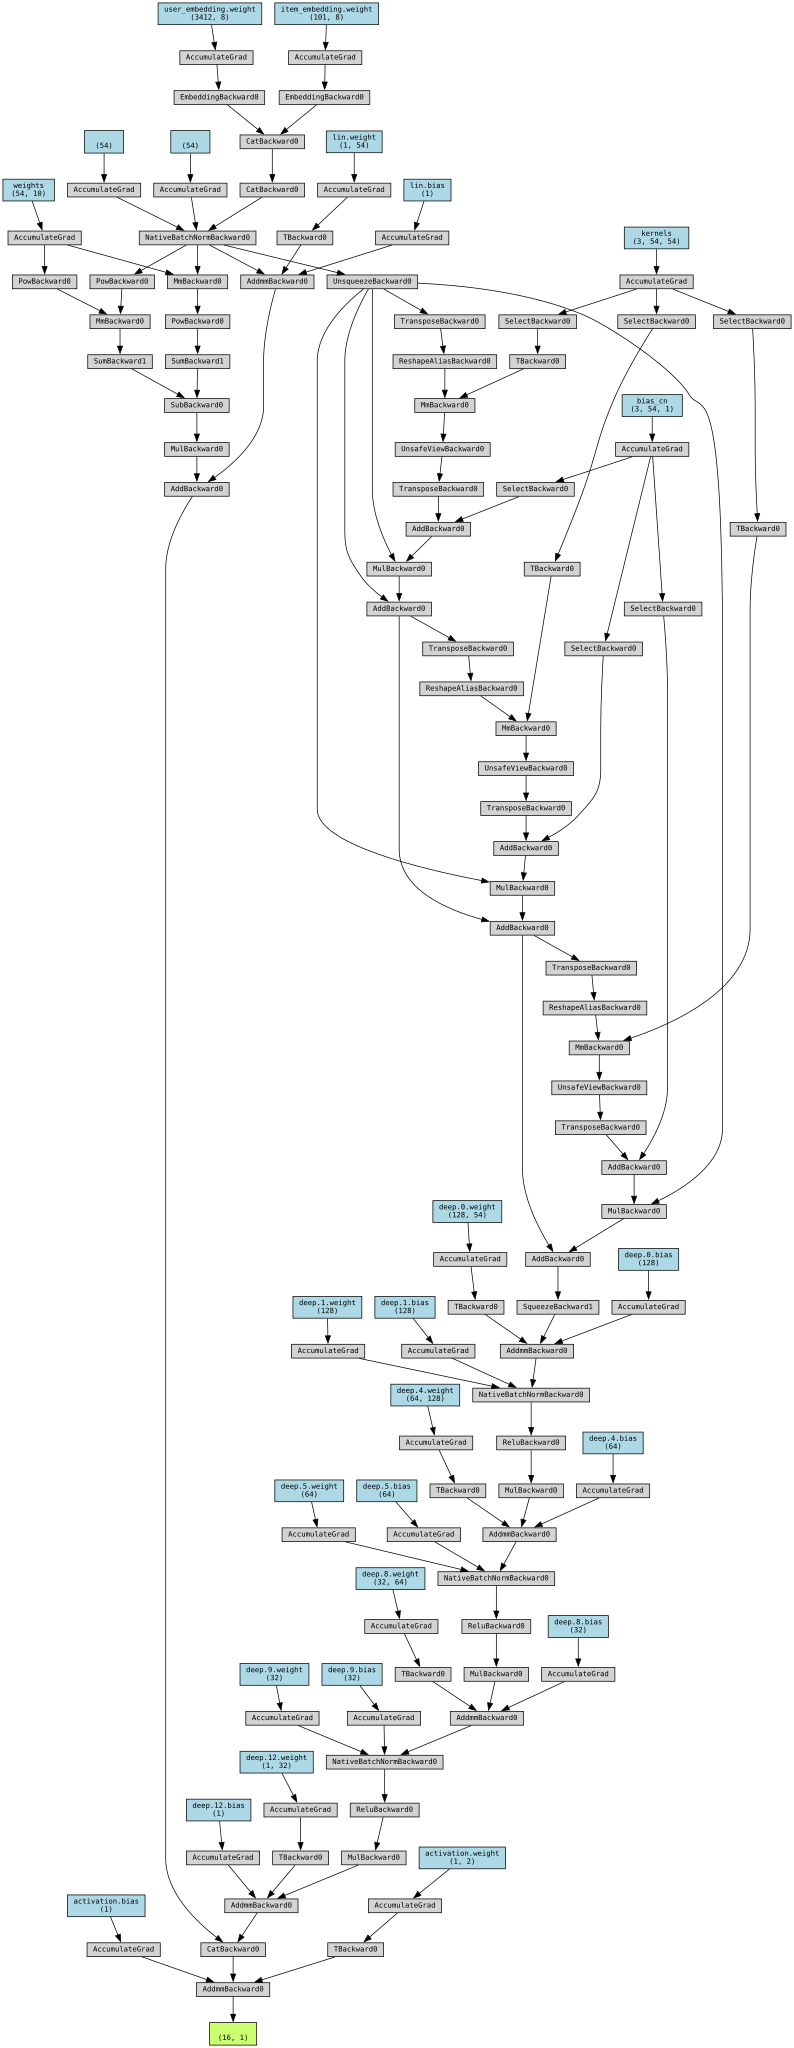

In [15]:
yhat = rcsys(*next(iter(train_loader_bi))[:-1])
make_dot(yhat, params=dict(list(rcsys.named_parameters())))

In [95]:
def trainModel(epochs, model, loss_func, trainloader, testloader, optimizer, patience, 
               save_model = True, save_model_name = 'best_model',
               scheduler=None, clip_threshold=1.0, recallatKinputs=None):
    train_loss_lst = []
    train_loss = 0
    test_loss_lst = []
    test_loss = 0
    accuracy_lst = []
    auc_lst = []
    precision_lst = []
    recall_lst = []
    f1_lst = []
    e = 0
    best_f1 = 0
    best_test_loss = 10000000
    best_epoch = 0
    earlystop = False
    print('---------Start Training---------')
    while e < epochs | earlystop:
        # train
        model.train()
        for i, train_batch in enumerate(trainloader):
            optimizer.zero_grad()
            predict = model(*train_batch[:-1]).to(torch.float64)
            if predict.isnan().sum().item() > 0:
                print('NAN')
            actual = torch.unsqueeze(train_batch[-1],1).to(torch.float64)
            loss = loss_func(predict, actual)
            train_loss += loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_threshold)
            optimizer.step()
        train_loss /= len(trainloader)
        train_loss_lst.append(train_loss.item())
        
        # evaluate
        with torch.no_grad():
            model.eval()
            prediction = []
            target = []
            for test_batch in testloader:
                predict = model(*test_batch[:-1]).to(torch.float64)
                if predict.isnan().sum().item() > 0:
                    print('NAN FOUND')
                actual = torch.unsqueeze(test_batch[-1],1)
                prediction.extend(nn.Sigmoid()(predict).squeeze(1).tolist())
                target.extend(test_batch[-1].tolist())
                loss = loss_func(predict, actual.to(torch.float64))
                test_loss += loss
            accuracy = sum(1 for x,y in zip([round(i) for i in prediction],target) if x == y) / len(prediction)
            accuracy_lst.append(accuracy)
            auc = roc_auc_score(target,prediction)
            auc_lst.append(auc)
            precision = precision_score(target,[round(i) for i in prediction])
            precision_lst.append(precision)
            recall = recall_score(target,[round(i) for i in prediction])
            recall_lst.append(recall)
            f1 = 2 * (precision * recall) / (precision + recall)
            f1_lst.append(f1)
            test_loss /= len(testloader)
            test_loss_lst.append(test_loss.item())
        
        print('Epoch:', e, 'Train loss:', train_loss.item(), 'Test loss:', test_loss.item(), '\n', 'Test accuracy:', accuracy, 'Test AUC:', auc, '\n','Test Precision:', precision, 'Test Recall:', recall, '\n', 'F1 Score:', f1)
        print('Positive prediction:', sum(1 for x,y in zip([round(i) for i in prediction],target) if x == y and y == 1))
        if f1 > best_f1:
            best_f1 = f1
            best_epoch = e
            if save_model:
                torch.save({
                    'optimizer': optimizer.state_dict(),
                    'model': model.state_dict(),
                    'epoch': e
                }, model_path+'/'+save_model_name+'.pth')        
        elif e - best_epoch > patience:
            print("Early stopped training at epoch %d" %e + ', with the best epoch at %d' %best_epoch)
            print('The best F1 Score is ' + str(best_f1))
            break  
        print('--------------------------------------')
        if recallatKinputs != None:
            print('Recall@10: ', recallAtK(model,recallatKinputs['current'],recallatKinputs['future'],recallatKinputs['k']))
            print('Precision@10: ', precisionAtK(model,recallatKinputs['current'],recallatKinputs['future'],recallatKinputs['k']))
            print('--------------------------------------')


        if scheduler:
            scheduler.step()
        train_loss = 0
        test_loss = 0
        e += 1
        
    return train_loss_lst, test_loss_lst, accuracy_lst, auc_lst, precision_lst, recall_lst

In [28]:
def evalModel(model, evaldata):
    with torch.no_grad():
        model.eval()
        prediction = []
        target = []
        for test_batch in evaldata:
            predict = model(*test_batch[:-1]).to(torch.float64)
            if predict.isnan().sum().item() > 0:
                print('NAN FOUND')
            actual = torch.unsqueeze(test_batch[-1],1)
            prediction.extend(nn.Sigmoid()(predict).squeeze(1).tolist())
            target.extend(test_batch[-1].tolist())
        accuracy = sum(1 for x,y in zip([round(i) for i in prediction],target) if x == y) / len(prediction)
        auc = roc_auc_score(target,prediction)
        precision = precision_score(target,[round(i) for i in prediction])
        recall = recall_score(target,[round(i) for i in prediction])
        f1 = 2 * (precision * recall) / (precision + recall)
        return {
            'Accuracy': accuracy,
            'AUC': auc,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'Actual Positive': sum(target),
            'Predicted Positive': sum([round(i) for i in prediction])
        }

In [23]:
# some hyperparamters 
pos_weight = (len(train_loader_bi.dataset.target)-train_loader_bi.dataset.target.sum())/train_loader_bi.dataset.target.sum()
num_epoch = 1000
num_user = len(np.unique(user_item_table.customer_id))
num_item = len(np.unique(user_item_table.product_id))

In [86]:
# MF train
mf = MF(num_users=num_user, num_items=num_item, emb_size=64, num_features=num_features)
optimizer = torch.optim.Adam(mf.parameters(), lr=0.00001, weight_decay=0.00001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
mf_train_loss_list, mf_test_loss_list, mf_accuracy_list, mf_auc_list, mf_precision_list, mf_recall_list = trainModel(
    num_epoch, mf, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)


---------Start Training---------
Epoch: 0 Train loss: 7.70147287672788 Test loss: 7.3523822478410095 
 Test accuracy: 0.4983541233541234 Test AUC: 0.5107212965745986 
 Test Precision: 0.05302606073659272 Test Recall: 0.510576524263791 
 F1 Score: 0.09607429953953016
Positive prediction: 1231
--------------------------------------
Epoch: 1 Train loss: 7.593430044859621 Test loss: 7.258830515982701 
 Test accuracy: 0.4996101871101871 Test AUC: 0.5107717432236185 
 Test Precision: 0.052888562416281384 Test Recall: 0.507673164661966 
 F1 Score: 0.0957971354778117
Positive prediction: 1224
--------------------------------------
Epoch: 2 Train loss: 7.4866705796732065 Test loss: 7.166968842843773 
 Test accuracy: 0.501039501039501 Test AUC: 0.5107996153999793 
 Test Precision: 0.05292358371982142 Test Recall: 0.5064288676897553 
 F1 Score: 0.09583235224864611
Positive prediction: 1221
--------------------------------------
Epoch: 3 Train loss: 7.380271928095627 Test loss: 7.076049469480147 


In [89]:
# FM train
fm = FM(num_users=num_user, num_items=num_item, emb_size=64, num_features=num_features)
optimizer = torch.optim.Adam(fm.parameters(), lr=0.00001, weight_decay=0.00001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
fm_train_loss_list, fm_test_loss_list, fm_accuracy_list, fm_auc_list, fm_precision_list, fm_recall_list = trainModel(
    num_epoch, fm, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)


---------Start Training---------
Epoch: 0 Train loss: 338.886162388159 Test loss: 336.78911164505143 
 Test accuracy: 0.606743762993763 Test AUC: 0.49154191007893167 
 Test Precision: 0.052661478157132305 Test Recall: 0.38464730290456434 
 F1 Score: 0.0926397841403088
Positive prediction: 927
--------------------------------------
Epoch: 1 Train loss: 328.7610992826706 Test loss: 329.58163728645184 
 Test accuracy: 0.6423899861399861 Test AUC: 0.49340958077868 
 Test Precision: 0.05220373428172234 Test Recall: 0.3409373703857321 
 F1 Score: 0.0905435920030842
Positive prediction: 822
--------------------------------------
Epoch: 2 Train loss: 323.3342704565046 Test loss: 328.0682980801546 
 Test accuracy: 0.676411988911989 Test AUC: 0.4947628881924372 
 Test Precision: 0.053325728951308195 Test Recall: 0.3102447117378681 
 F1 Score: 0.09100863852050127
Positive prediction: 748
--------------------------------------
Epoch: 3 Train loss: 321.87219730428455 Test loss: 328.3518067783641 
 

In [90]:
# DeepFM train
deepfm = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(deepfm.parameters(), lr=0.00001, weight_decay=0.00001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
deepfm_train_loss_list, deepfm_test_loss_list, deepfm_accuracy_list, deepfm_auc_list, deepfm_precision_list, deepfm_recall_list = trainModel(
    num_epoch, fm, loss_function, train_loader_bi, test_loader_bi, 
    optimizer, patience=3, clip_threshold=0.2, save_model=False)

---------Start Training---------
Epoch: 0 Train loss: 322.94134997254037 Test loss: 327.7047563815266 
 Test accuracy: 0.7303361053361054 Test AUC: 0.49894024602479126 
 Test Precision: 0.05503855357617655 Test Recall: 0.2575694732476151 
 F1 Score: 0.0906966554695487
Positive prediction: 621
--------------------------------------
Epoch: 1 Train loss: 324.0245191661428 Test loss: 329.7824285672196 
 Test accuracy: 0.7278023215523216 Test AUC: 0.4966033711117734 
 Test Precision: 0.05423907319641917 Test Recall: 0.2563251762754044 
 F1 Score: 0.08953277797899313
Positive prediction: 618
--------------------------------------
Epoch: 2 Train loss: 321.9009816706358 Test loss: 329.3035227759729 
 Test accuracy: 0.728473665973666 Test AUC: 0.49424708317697874 
 Test Precision: 0.053675304071919616 Test Recall: 0.25269709543568464 
 F1 Score: 0.08854318115731317
Positive prediction: 609
--------------------------------------
Epoch: 3 Train loss: 322.81866327119394 Test loss: 329.865296818752

In [107]:
# Deep and Cross FM train
DCN = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(DCN.parameters(), lr=0.00001, weight_decay=0.00001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
# scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.001, step_size_up=2, step_size_down=4, cycle_momentum=False, verbose=True)
train_loss_list, test_loss_list, accuracy_list, auc_list, precision_list, recall_list = trainModel(num_epoch, 
    DCN, loss_function, train_loader_bi, test_loader_bi, optimizer, patience=3, clip_threshold=0.2)

---------Start Training---------
Epoch: 0 Train loss: 157.46467889455351 Test loss: 154.7948224488926 
 Test accuracy: 0.4710239085239085 Test AUC: 0.4940693366817077 
 Test Precision: 0.05171852093174784 Test Recall: 0.5269709543568465 
 F1 Score: 0.09419268708744344
Positive prediction: 1270
--------------------------------------
Epoch: 1 Train loss: 152.27398280840265 Test loss: 147.46450923165276 
 Test accuracy: 0.47466216216216217 Test AUC: 0.4982445883459143 
 Test Precision: 0.05170927894283252 Test Recall: 0.5226047283284944 
 F1 Score: 0.09410710284561953
Positive prediction: 1260
--------------------------------------
Epoch: 2 Train loss: 145.68079178102712 Test loss: 140.42762659701265 
 Test accuracy: 0.4776940401940402 Test AUC: 0.5000630606805521 
 Test Precision: 0.05204506995748896 Test Recall: 0.523019493985898 
 F1 Score: 0.09466966966966968
Positive prediction: 1261
--------------------------------------
Epoch: 3 Train loss: 140.6109298165052 Test loss: 135.83756876

Epoch: 28 Train loss: 2.3983590514143645 Test loss: 1.6600337220093726 
 Test accuracy: 0.9922253984753985 Test AUC: 0.9874422624928785 
 Test Precision: 1.0 Test Recall: 0.8510991289921195 
 F1 Score: 0.9195608335200538
Positive prediction: 2052
--------------------------------------
Epoch: 29 Train loss: 1.9613569837802625 Test loss: 1.3888212672207727 
 Test accuracy: 0.9938279625779626 Test AUC: 0.9891257855397614 
 Test Precision: 0.9995300751879699 Test Recall: 0.882206553297387 
 F1 Score: 0.9372108393919366
Positive prediction: 2127
--------------------------------------
Epoch: 30 Train loss: 1.6967475488169554 Test loss: 1.1678905244222524 
 Test accuracy: 0.994585932085932 Test AUC: 0.9890648761628589 
 Test Precision: 1.0 Test Recall: 0.8963085856491082 
 F1 Score: 0.9453193350831146
Positive prediction: 2161
--------------------------------------
Epoch: 31 Train loss: 1.4854357349471727 Test loss: 0.8293380659509585 
 Test accuracy: 0.9962967775467776 Test AUC: 0.9920167490

In [24]:
best_rcsys = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(best_rcsys.parameters(), lr=0.00001, weight_decay=0.00001)

best_model_checkpoint = torch.load(model_path+'/best_model.pth')
best_rcsys.load_state_dict(best_model_checkpoint['model'])
optimizer.load_state_dict(best_model_checkpoint['optimizer'])
best_epoch = best_model_checkpoint['epoch']

In [25]:
evalModel(best_rcsys, test_loader_bi)

{'Accuracy': 0.9985923423423423,
 'AUC': 0.9961157407049822,
 'Precision': 0.9974554707379135,
 'Recall': 0.9755288262131896,
 'F1 Score': 0.9863703082407214,
 'Actual Positive': 2411,
 'Predicted Positive': 2358}

In [66]:
evalModel(best_rcsys, val_loader_bi)

{'Accuracy': 0.9981966924700915,
 'AUC': 0.9972851941653754,
 'Precision': 0.9983883964544722,
 'Recall': 0.9694835680751174,
 'F1 Score': 0.983723699880905,
 'Actual Positive': 1278,
 'Predicted Positive': 1241}

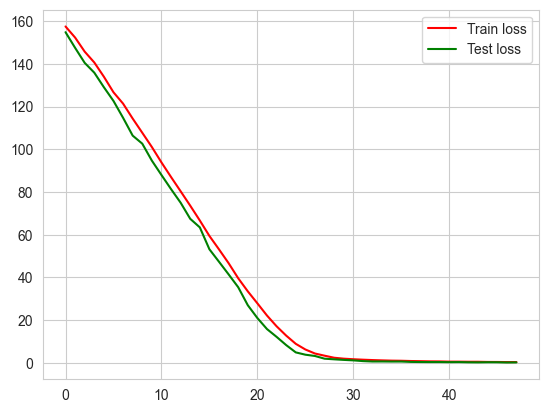

In [111]:
plt.plot(train_loss_list, 'r', label='Train loss')
plt.plot(test_loss_list, 'g', label='Test loss')
plt.legend()   
# plt.ylim(-1,5)

(0.0, 1.0)

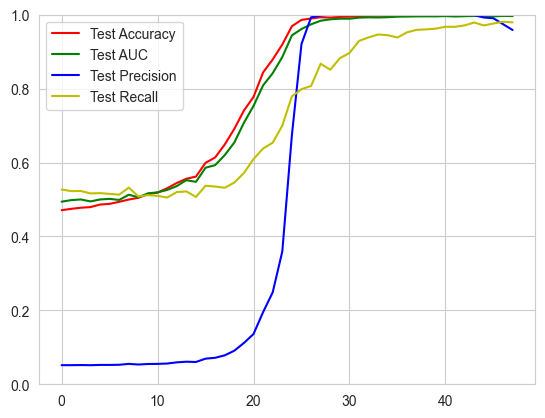

In [112]:
plt.plot(accuracy_list, 'r', label='Test Accuracy')
plt.plot(auc_list, 'g', label='Test AUC')
plt.plot(precision_list, 'b', label='Test Precision')
plt.plot(recall_list, 'y', label='Test Recall')
plt.legend()   
plt.ylim(0,1)

In [29]:
def getNextNRecommendation(model, user_id, n, full_data):
    input_data = transactionDataset(full_data[full_data.customer_id==user_id])
    input_data = DataLoader(dataset=input_data, batch_size=input_data.get_num_item())
    model.eval()
    prediction = []
    for batch in input_data:
        predict = model(*batch[:-1]).to(torch.float64)
        if predict.isnan().sum().item() > 0:
            print('NAN FOUND')
        prediction.extend(nn.Sigmoid()(predict).squeeze(1).tolist())
    purchased_item = full_data[np.logical_and(full_data.customer_id==user_id, full_data.target==1)].product_id.tolist()
    prediction = np.argsort(prediction)
    item_to_recommend = [i for i in prediction if i not in purchased_item]
    return item_to_recommend[::-1][:n]

In [30]:
getNextNRecommendation(best_rcsys,2919,5,user_item_table)

[2, 89, 56, 83, 22]

### Simulating the Data Updates

In [101]:
def getTimePartitionDate(data, partition_ratio):
    split_at = round(partition_ratio*len(user_item_table[user_item_table.quantity>0]))
    zeros = data[data.quantity==0]
    current = data[data.quantity>0].sort_values('day')[:split_at]
    future = data[data.quantity>0].sort_values('day')[split_at:]
    future_zeros = future.copy()
    future_zeros['quantity'] = 0
    future_zeros['target'] = 0
    current = pd.concat([current, future_zeros, zeros])
    return current, future

In [118]:
def recallAtK(model,current,future,k):
    predict = 0
    actual = 0
    positive = 0
    for j in future.customer_id.unique():
        product_id_list = set(future[future.customer_id==j].product_id.tolist())
        predicted_product_id_list = set(getNextNRecommendation(model,j,k,current))
        actual += len(product_id_list)
        positive += len(predicted_product_id_list)
        predict += len(product_id_list & predicted_product_id_list)
    print('actual positive', actual,'predicted positive',positive,'true prediction', predict)
    return predict/actual

In [119]:
def precisionAtK(model,current,future,k):
    predict = 0
    positive = 0
    for j in future.customer_id.unique():
        product_id_list = set(future[future.customer_id==j].product_id.tolist())
        predicted_product_id_list = set(getNextNRecommendation(model,j,k,current))
        positive += len(predicted_product_id_list)
        predict += len(product_id_list & predicted_product_id_list)
    return predict/positive

In [102]:
current, future = getTimePartitionDate(user_item_table,0.95)

In [103]:
current.target.value_counts()

0    327143
1     17469
Name: target, dtype: int64

In [104]:
future.target.value_counts()

1    919
Name: target, dtype: int64

In [71]:
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

In [42]:
# DCN with recall@k
DCN = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(DCN.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    DCN, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_95', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 44.46991476453679 Test loss: 0.2835679163128437 
 Test accuracy: 0.9954088704088704 Test AUC: 0.9920492796382476 
 Test Precision: 0.9411276948590381 Test Recall: 0.9700854700854701 
 F1 Score: 0.9553872053872053
Positive prediction: 2270
--------------------------------------
0.17410228509249184
--------------------------------------
Epoch: 1 Train loss: 0.10414467118314528 Test loss: 0.2851565796594961 
 Test accuracy: 0.9954088704088704 Test AUC: 0.99315174742221 
 Test Precision: 0.9414937759336099 Test Recall: 0.9696581196581197 
 F1 Score: 0.9553684210526315
Positive prediction: 2269
--------------------------------------
0.16648531011969533
--------------------------------------
Epoch: 2 Train loss: 0.10168059847423895 Test loss: 0.21831715461165538 
 Test accuracy: 0.9941311503811504 Test AUC: 0.9957546016504406 
 Test Precision: 0.9126445951336258 Test Recall: 0.9777777777777777 
 F1 Score: 0.9440891272952341
Positive predi

In [75]:
best_rcsys_current = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(best_rcsys_current.parameters(), lr=0.0001, weight_decay=0.0001)

best_current_model_checkpoint = torch.load(model_path+'/best_current_model_95.pth')
best_rcsys_current.load_state_dict(best_current_model_checkpoint['model'])
optimizer.load_state_dict(best_current_model_checkpoint['optimizer'])
best_epoch = best_current_model_checkpoint['epoch']

print(evalModel(best_rcsys_current, test_loader_current))
print(evalModel(best_rcsys_current, val_loader_current))

{'Accuracy': 0.9956687456687456, 'AUC': 0.9928240984461899, 'Precision': 0.9410552349546579, 'Recall': 0.9756410256410256, 'F1 Score': 0.9580360889634914, 'Actual Positive': 2340, 'Predicted Positive': 2426}
{'Accuracy': 0.9959975369458128, 'AUC': 0.9944585368356578, 'Precision': 0.9486099410278012, 'Recall': 0.9740484429065744, 'F1 Score': 0.9611609048228767, 'Actual Positive': 1156, 'Predicted Positive': 1187}
5 0.11316648531011969
10 0.17410228509249184
15 0.21980413492927095
20 0.27529923830250275


In [120]:
for i in [5,10,15,20]:
    print('K = ', i, 'Recall@K = ', recallAtK(best_rcsys_current,current,future,i))

actual positive 919 predicted positive 4035 true prediction 104
K =  5 Recall@K =  0.11316648531011969
actual positive 919 predicted positive 8070 true prediction 160
K =  10 Recall@K =  0.17410228509249184
actual positive 919 predicted positive 12105 true prediction 202
K =  15 Recall@K =  0.21980413492927095
actual positive 919 predicted positive 16140 true prediction 253
K =  20 Recall@K =  0.27529923830250275


In [93]:
for i in [5,10,15,20]:
    print('K = ', i, 'Precision@K = ', precisionAtK(best_rcsys_current,current,future,i))

K =  5 Precision@K =  0.02577447335811648
K =  10 Precision@K =  0.01982651796778191
K =  15 Precision@K =  0.016687319289549772
K =  20 Precision@K =  0.015675340768277573


In [78]:
# DFM with recall@k
deepfm = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(deepfm.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    deepfm, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_95_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 17.132877603400676 Test loss: 0.37286554057507554 
 Test accuracy: 0.9948674636174636 Test AUC: 0.9929249892567714 
 Test Precision: 0.9408805031446541 Test Recall: 0.958974358974359 
 F1 Score: 0.9498412698412699
Positive prediction: 2244
--------------------------------------
0.17519042437431992
--------------------------------------
Epoch: 1 Train loss: 0.2635121324968597 Test loss: 0.3041435067280752 
 Test accuracy: 0.9953439015939016 Test AUC: 0.9915723687921079 
 Test Precision: 0.9366776315789473 Test Recall: 0.9739204788371099 
 F1 Score: 0.9549360721022846
Positive prediction: 2278
--------------------------------------
0.18171926006528835
--------------------------------------
Epoch: 2 Train loss: 0.22636434000298009 Test loss: 0.3069241218695129 
 Test accuracy: 0.995213963963964 Test AUC: 0.9946450854505878 
 Test Precision: 0.9405405405405406 Test Recall: 0.9666666666666667 
 F1 Score: 0.9534246575342465
Positive predi

/Users/chonge/opt/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/var/folders/l2/7wq9m36d0nvcw9qptmy_19fm0000gn/T/ipykernel_18190/3573977422.py:58: RuntimeWarning: invalid value encountered in double_scalars
  f1 = 2 * (precision * recall) / (precision + recall)


Epoch: 3 Train loss: 0.20502650584298981 Test loss: 8.930381492840107 
 Test accuracy: 0.9493243243243243 Test AUC: 0.9932012423149843 
 Test Precision: 0.0 Test Recall: 0.0 
 F1 Score: nan
Positive prediction: 0
--------------------------------------
0.17519042437431992
--------------------------------------
Epoch: 4 Train loss: 0.17740864452164 Test loss: 3.5408934145386146 
 Test accuracy: 0.9544352044352045 Test AUC: 0.9941218941150506 
 Test Precision: 0.9402985074626866 Test Recall: 0.1076923076923077 
 F1 Score: 0.19325153374233128
Positive prediction: 252
--------------------------------------
0.16539717083786726
--------------------------------------


/Users/chonge/opt/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/var/folders/l2/7wq9m36d0nvcw9qptmy_19fm0000gn/T/ipykernel_18190/3573977422.py:58: RuntimeWarning: invalid value encountered in double_scalars
  f1 = 2 * (precision * recall) / (precision + recall)


Epoch: 5 Train loss: 0.1721510509360424 Test loss: 8.7171439714727 
 Test accuracy: 0.9493243243243243 Test AUC: 0.9949583743759763 
 Test Precision: 0.0 Test Recall: 0.0 
 F1 Score: nan
Positive prediction: 0
Early stopped training at epoch 5, with the best epoch at 1
The best F1 Score is 0.9549360721022846


In [121]:
best_deepfm_current = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(best_deepfm_current.parameters(), lr=0.0001, weight_decay=0.0001)

best_current_model_checkpoint = torch.load(model_path+'/best_current_model_95_dfm.pth')
best_deepfm_current.load_state_dict(best_current_model_checkpoint['model'])
optimizer.load_state_dict(best_current_model_checkpoint['optimizer'])
best_epoch = best_current_model_checkpoint['epoch']

for i in [5,10,15,20]:
    print('K = ', i, 'Recall@K = ', recallAtK(best_deepfm_current,current,future,i))
for i in [5,10,15,20]:
    print('K = ', i, 'Precision@K = ', precisionAtK(best_deepfm_current,current,future,i))

actual positive 919 predicted positive 4035 true prediction 108
K =  5 Recall@K =  0.117519042437432
actual positive 919 predicted positive 8070 true prediction 167
K =  10 Recall@K =  0.18171926006528835
actual positive 919 predicted positive 12105 true prediction 208
K =  15 Recall@K =  0.22633297062023938
actual positive 919 predicted positive 16140 true prediction 255
K =  20 Recall@K =  0.27747551686615884
K =  5 Precision@K =  0.026765799256505577
K =  10 Precision@K =  0.020693928128872368
K =  15 Precision@K =  0.01718298223874432
K =  20 Precision@K =  0.015799256505576207


In [122]:
# with different time split - 85%
current, future = getTimePartitionDate(user_item_table,0.85)
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

DCN = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(DCN.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    DCN, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_85', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 34.28701399777865 Test loss: 0.33123988539539156 
 Test accuracy: 0.9903629591129591 Test AUC: 0.9902479888789547 
 Test Precision: 0.847926267281106 Test Recall: 0.9610636277302944 
 F1 Score: 0.9009570442911194
Positive prediction: 2024
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 463
Recall@10:  0.16787527193618565
Precision@10:  0.024497354497354497
--------------------------------------
Epoch: 1 Train loss: 0.16005614842057395 Test loss: 0.2006058840845137 
 Test accuracy: 0.9910343035343036 Test AUC: 0.9931466731141492 
 Test Precision: 0.8478618421052632 Test Recall: 0.9791073124406457 
 F1 Score: 0.9087703834288232
Positive prediction: 2062
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 464
Recall@10:  0.16823785351704135
Precision@10:  0.02455026455026455
--------------------------------------
Epoch: 2 Train loss: 0

In [125]:
# dfm with different time split - 85%
deepfm = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(deepfm.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    deepfm, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_85_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 0.627106759323105 Test loss: 0.3484309364413247 
 Test accuracy: 0.9901247401247402 Test AUC: 0.9931466300160046 
 Test Precision: 0.8475147430497051 Test Recall: 0.9553656220322887 
 F1 Score: 0.8982142857142857
Positive prediction: 2012
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 460
Recall@10:  0.16678752719361856
Precision@10:  0.02433862433862434
--------------------------------------
Epoch: 1 Train loss: 0.3344653553453648 Test loss: 0.3247606456547861 
 Test accuracy: 0.9902113652113652 Test AUC: 0.9933444828233421 
 Test Precision: 0.847771236333053 Test Recall: 0.9572649572649573 
 F1 Score: 0.8991971454058876
Positive prediction: 2016
--------------------------------------
actual positive 2758 predicted positive 18900 true prediction 465
Recall@10:  0.16860043509789702
Precision@10:  0.024603174603174603
--------------------------------------
Epoch: 2 Train loss: 0.2

In [123]:
# with different time split - 99%
current, future = getTimePartitionDate(user_item_table,0.99)
train_current, test_current, val_current = train_tet_val_split(current)
train_loader_current = DataLoader(dataset=train_current, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_current = DataLoader(dataset=test_current, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_current = DataLoader(dataset=val_current, batch_size=batch_size, shuffle=True, drop_last=True)

DCN = RecSys(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(DCN.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    DCN, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_99', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 39.08776539906397 Test loss: 0.2837534679253314 
 Test accuracy: 0.997920997920998 Test AUC: 0.9941087122311761 
 Test Precision: 0.985962014863749 Test Recall: 0.9746938775510204 
 F1 Score: 0.9802955665024631
Positive prediction: 2388
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 30
Recall@10:  0.16304347826086957
Precision@10:  0.016483516483516484
--------------------------------------
Epoch: 1 Train loss: 0.09704396049245662 Test loss: 0.185879716769194 
 Test accuracy: 0.9982241857241857 Test AUC: 0.9966200840671081 
 Test Precision: 0.9860426929392446 Test Recall: 0.9804081632653061 
 F1 Score: 0.9832173557101923
Positive prediction: 2402
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 31
Recall@10:  0.16847826086956522
Precision@10:  0.01703296703296703
--------------------------------------
Epoch: 2 Train loss: 0.08750058

In [124]:
# dfm with different time split - 99%
deepfm = DeepFM(num_users=num_user, num_items=num_item, emb_size=64, deep_param=[1024,512,256], num_features=num_features)
optimizer = torch.optim.Adam(deepfm.parameters(), lr=0.0001, weight_decay=0.0001)
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight*1.5))
cur_train_loss_list, cur_test_loss_list, cur_accuracy_list, cur_auc_list, cur_precision_list, cur_recall_list = trainModel(num_epoch, 
    deepfm, loss_function, train_loader_current, test_loader_current, optimizer, patience=3, clip_threshold=0.2, 
    save_model_name = 'best_current_model_99_dfm', recallatKinputs={'current': current,'future': future,'k': 10})

---------Start Training---------
Epoch: 0 Train loss: 0.5234547637183752 Test loss: 0.27872731793970595 
 Test accuracy: 0.9973362785862786 Test AUC: 0.9975171359308943 
 Test Precision: 0.98580375782881 Test Recall: 0.9636734693877551 
 F1 Score: 0.9746130030959753
Positive prediction: 2361
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 32
Recall@10:  0.17391304347826086
Precision@10:  0.017582417582417582
--------------------------------------
Epoch: 1 Train loss: 0.27072969662687985 Test loss: 0.23387948719880144 
 Test accuracy: 0.9971846846846847 Test AUC: 0.9978474582441492 
 Test Precision: 0.9754098360655737 Test Recall: 0.9714285714285714 
 F1 Score: 0.9734151329243353
Positive prediction: 2380
--------------------------------------
actual positive 184 predicted positive 1820 true prediction 29
Recall@10:  0.15760869565217392
Precision@10:  0.015934065934065933
--------------------------------------
Epoch: 2 Train loss: 0.219

/Users/chonge/opt/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/var/folders/l2/7wq9m36d0nvcw9qptmy_19fm0000gn/T/ipykernel_18190/2556315697.py:58: RuntimeWarning: invalid value encountered in double_scalars
  f1 = 2 * (precision * recall) / (precision + recall)


Epoch: 4 Train loss: 0.15475458437177833 Test loss: 12.679459917366332 
 Test accuracy: 0.9469421344421345 Test AUC: 0.9962743037113304 
 Test Precision: 0.0 Test Recall: 0.0 
 F1 Score: nan
Positive prediction: 0
Early stopped training at epoch 4, with the best epoch at 0
The best F1 Score is 0.9746130030959753


In [ ]:
# Summary recall and precision at 10
# Binary Prediction
# ----------------------------------------------------------
#   Model |Split|     Recall@10      |     Precission@10
# ----------------------------------------------------------
#   DCN   | 95  |0.17410228509249184 | 0.01982651796778191
# ----------------------------------------------------------
#   DFM   | 95  |0.18171926006528835 | 0.020693928128872368
# ----------------------------------------------------------
#   DCN   | 85  |0.16823785351704135  | 0.02455026455026455
# ----------------------------------------------------------
#   DFM   | 85  |0.1693255982596084  | 0.024708994708994708
# ----------------------------------------------------------
#   DCN   | 99  |0.16847826086956522 | 0.01703296703296703
# ----------------------------------------------------------
#   DFM   | 99  |0.17391304347826086 | 0.017582417582417582
# ----------------------------------------------------------